# 可解釋的AI(eXplainable AI, XAI)

## 載入套件

In [1]:
!pip install torchsummary

In [2]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image
import torch
from torch import nn
from torchsummary import summary
from torchvision import models, transforms

In [3]:
# 判斷是否為 Colab 環境
is_colab = 'google.colab' in sys.modules
base_path = Path('/content/drive/MyDrive/colab_env') if is_colab else Path('.')
PATH_DATASETS = base_path / "data"  # 預設路徑

## 檢查 GPU

In [4]:
device = "cuda" if torch.cuda.is_available() else "mps" if torch.mps.is_available() else "cpu"
device

'mps'

In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"

## 使用預先訓練的模型

In [6]:
rn18 = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

## 顯示神經層名稱

In [7]:
children_counter = 0
for n, c in rn18.named_children():
    print("Children Counter: ", children_counter, " Layer Name: ", n)
    children_counter += 1

Children Counter:  0  Layer Name:  conv1
Children Counter:  1  Layer Name:  bn1
Children Counter:  2  Layer Name:  relu
Children Counter:  3  Layer Name:  maxpool
Children Counter:  4  Layer Name:  layer1
Children Counter:  5  Layer Name:  layer2
Children Counter:  6  Layer Name:  layer3
Children Counter:  7  Layer Name:  layer4
Children Counter:  8  Layer Name:  avgpool
Children Counter:  9  Layer Name:  fc


## 顯示神經層明細

In [8]:
rn18._modules

{'conv1': Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False),
 'bn1': BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True),
 'relu': ReLU(inplace=True),
 'maxpool': MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False),
 'layer1': Sequential(
   (0): BasicBlock(
     (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
     (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
     (relu): ReLU(inplace=True)
     (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
     (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
   )
   (1): BasicBlock(
     (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
     (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
     (relu

In [9]:
summary(rn18.to(device), input_size=(3, 224, 224), device=device)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]          36,864
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
       BasicBlock-11           [-1, 64, 56, 56]               0
           Conv2d-12           [-1, 64, 56, 56]          36,864
      BatchNorm2d-13           [-1, 64, 56, 56]             128
             ReLU-14           [-1, 64,

## 移除 layer1 後面的神經層

In [10]:
class NewModel(nn.Module):
    def __init__(self, output_layer: str):
        super(NewModel, self).__init__()
        self.output_layer = output_layer
        self.pretrained = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.children_list = []
        # 依序取得每一層
        for n, c in self.pretrained.named_children():
            self.children_list.append(c)
            # 找到特定層即終止
            if n == self.output_layer:
                print('found !!')
                break

        # 建構新模型
        self.net = nn.Sequential(*self.children_list)
        self.pretrained = None

    def forward(self, x: torch.Tensor):
        x = self.net(x)
        return x


model = NewModel(output_layer='layer1')
model = model.to(device)

found !!


In [11]:
summary(model, input_size=(3, 224, 224), device=device)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]          36,864
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
       BasicBlock-11           [-1, 64, 56, 56]               0
           Conv2d-12           [-1, 64, 56, 56]          36,864
      BatchNorm2d-13           [-1, 64, 56, 56]             128
             ReLU-14           [-1, 64,

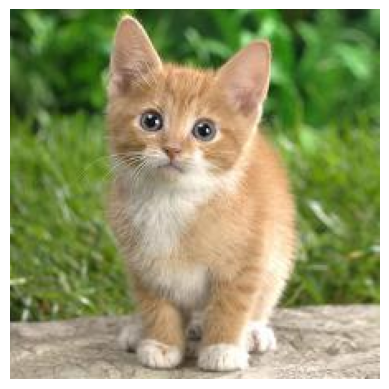

torch.Size([1, 64, 56, 56])

In [12]:
img = Image.open(base_path / "images_test/cat.jpg")
plt.imshow(img)
plt.axis('off')
plt.show()

resize = transforms.Resize([224, 224])
img = resize(img)

to_tensor = transforms.ToTensor()
img = to_tensor(img).to(device)
img = img.reshape(1, *img.shape)
out: torch.Tensor = model(img)
out.shape

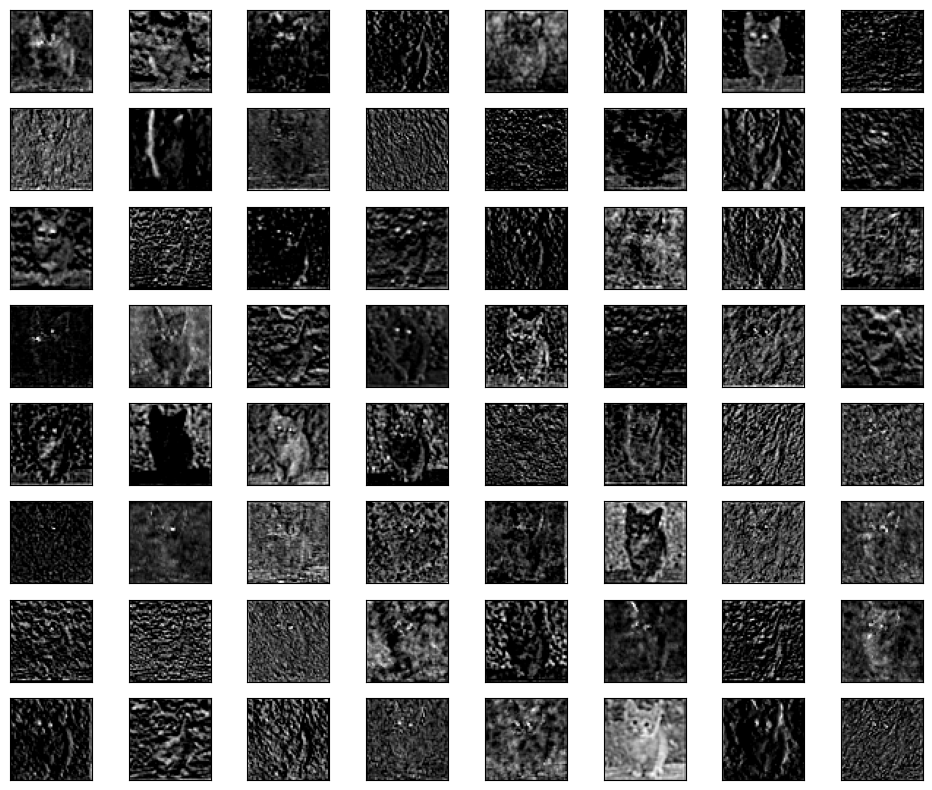

In [13]:
# 重建 8x8 圖像
def show_grid(out: torch.Tensor):
    square = 8
    plt.figure(figsize=(12, 10))
    for fmap in out.cpu().detach().numpy():
        # plot all 64 maps in an 8x8 squares
        ix = 1
        for _ in range(square):
            for _ in range(square):
                # specify subplot and turn of axis
                ax = plt.subplot(square, square, ix)
                ax.set_xticks([])
                ax.set_yticks([])
                # plot filter channel in grayscale
                plt.imshow(fmap[ix - 1, :, :], cmap='gray')
                ix += 1
        # show the figure
        plt.show()


show_grid(out)

found !!


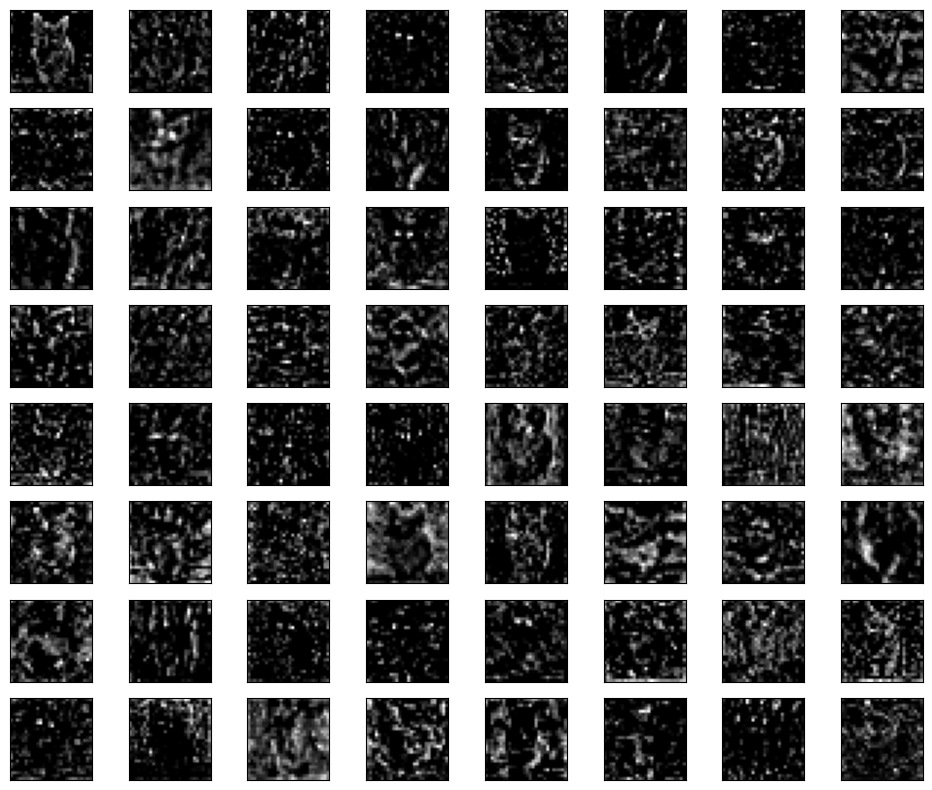

In [14]:
model = NewModel(output_layer='layer2').to(device)
out: torch.Tensor = model(img)
show_grid(out)

found !!


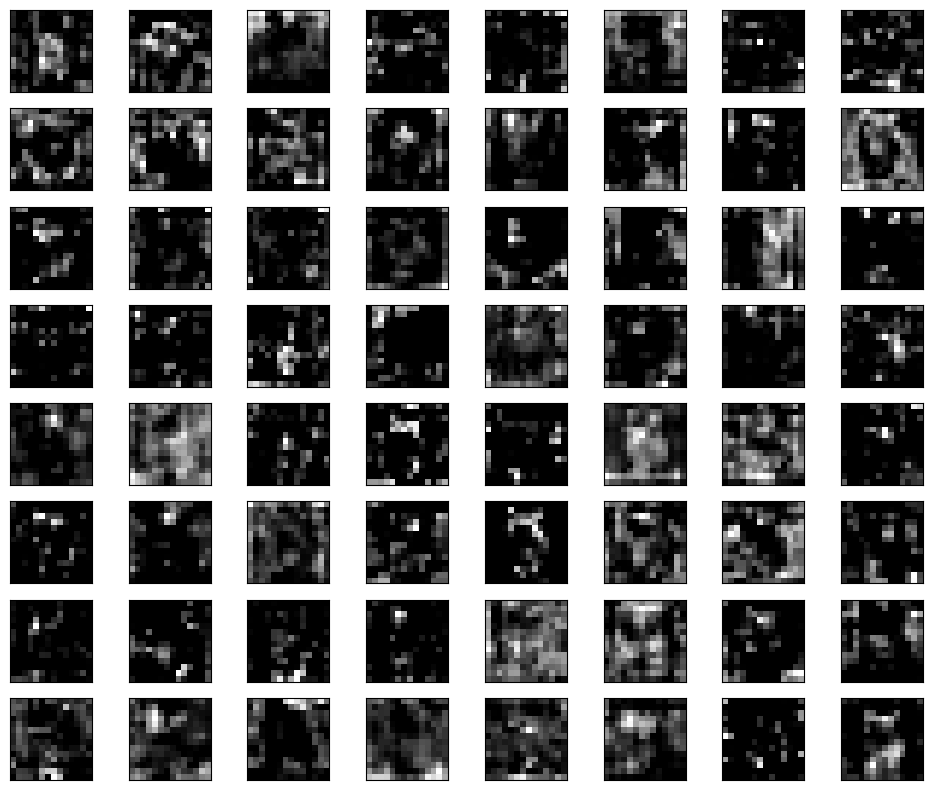

In [15]:
model = NewModel(output_layer='layer3').to(device)
out: torch.Tensor = model(img)
show_grid(out)

found !!


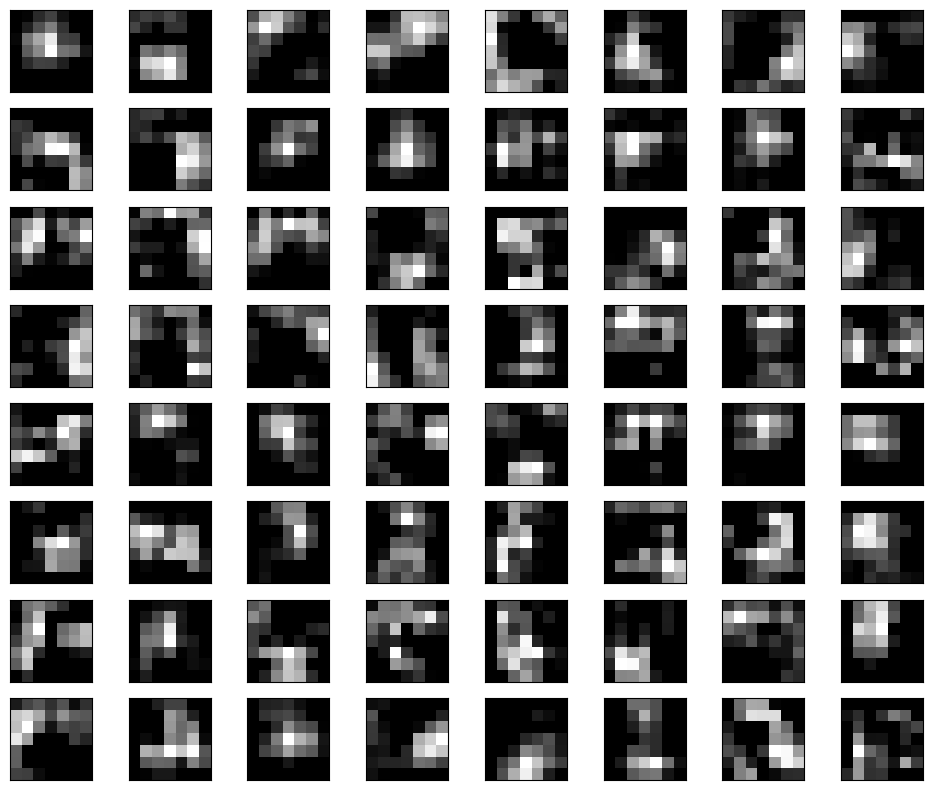

In [16]:
model = NewModel(output_layer='layer4').to(device)
out: torch.Tensor = model(img)
show_grid(out)